In [ ]:
import random
import torch
import numpy as np

torch.manual_seed(11231)
np.random.seed(11231)
random.seed(11231)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(11231)

Trening se izvršava na: cuda
Epoha 1/30 | Loss: -2.3684
Epoha 2/30 | Loss: -2.8977
Epoha 3/30 | Loss: -2.9415
Epoha 4/30 | Loss: -2.9606
Epoha 5/30 | Loss: -2.9747
Epoha 6/30 | Loss: -2.9862
Epoha 7/30 | Loss: -2.9896
Epoha 8/30 | Loss: -3.0009
Epoha 9/30 | Loss: -3.0061
Epoha 10/30 | Loss: -3.0133
Epoha 11/30 | Loss: -3.0180
Epoha 12/30 | Loss: -3.0202
Epoha 13/30 | Loss: -3.0275
Epoha 14/30 | Loss: -3.0304
Epoha 15/30 | Loss: -3.0333
Epoha 16/30 | Loss: -3.0371
Epoha 17/30 | Loss: -3.0420
Epoha 18/30 | Loss: -3.0476
Epoha 19/30 | Loss: -3.0502
Epoha 20/30 | Loss: -3.0548
Epoha 21/30 | Loss: -3.0597
Epoha 22/30 | Loss: -3.0628
Epoha 23/30 | Loss: -3.0711
Epoha 24/30 | Loss: -3.0775
Epoha 25/30 | Loss: -3.0768
Epoha 26/30 | Loss: -3.0861
Epoha 27/30 | Loss: -3.0924
Epoha 28/30 | Loss: -3.0997
Epoha 29/30 | Loss: -3.1057
Epoha 30/30 | Loss: -3.1116


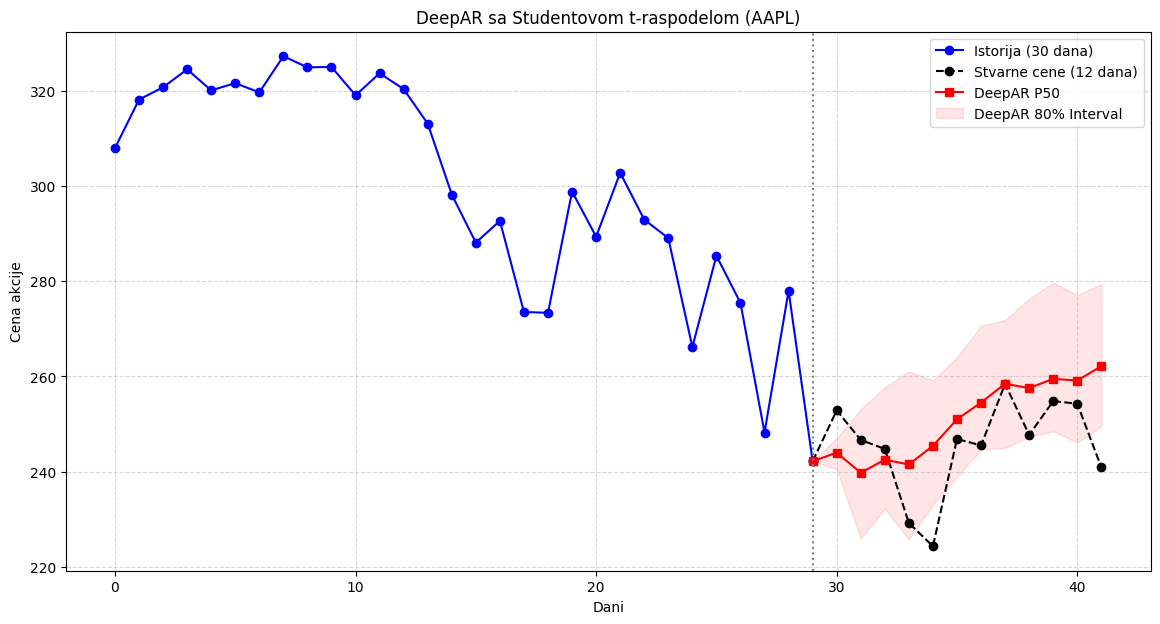

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class DeepAR(nn.Module):
    def __init__(self, input_size=4, hidden_size=64, num_layers=2):
        super(DeepAR, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear_mu = nn.Linear(hidden_size, 1)
        self.linear_sigma = nn.Linear(hidden_size, 1)
        self.linear_df = nn.Linear(hidden_size, 1)
        self.softplus = nn.Softplus()

    def forward(self, x, hidden=None):
        if hidden is None:
            h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
            c_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
            hidden = (h_0, c_0)
        lstm_out, hidden = self.lstm(x, hidden)
        mu = self.linear_mu(lstm_out)
        sigma = self.softplus(self.linear_sigma(lstm_out)) + 1e-4
        df = self.softplus(self.linear_df(lstm_out)) + 2.0
        return mu, sigma, df, hidden

class GlobalStockDataset(Dataset):
    def __init__(self, df_pivot, seq_len=30, pred_len=12):
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.window_size = seq_len + pred_len
        self.data_matrix = torch.tensor(df_pivot.values, dtype=torch.float32)
        self.num_tickers = df_pivot.shape[1]
        self.num_windows = len(df_pivot) - self.window_size + 1
        day_of_week = df_pivot.index.dayofweek.values / 6.0
        month_of_year = (df_pivot.index.month.values - 1) / 11.0
        self.day_of_week = torch.tensor(day_of_week, dtype=torch.float32)
        self.month_of_year = torch.tensor(month_of_year, dtype=torch.float32)

    def __len__(self):
        return self.num_windows * self.num_tickers

    def __getitem__(self, idx):
        window_idx = idx // self.num_tickers
        ticker_idx = idx % self.num_tickers
        window = self.data_matrix[window_idx : window_idx + self.window_size, ticker_idx]
        v = 1.0 + torch.mean(window[:self.seq_len])
        window_scaled = window / v
        age = torch.arange(self.window_size, dtype=torch.float32) / self.window_size
        dow_window = self.day_of_week[window_idx : window_idx + self.window_size]
        moy_window = self.month_of_year[window_idx : window_idx + self.window_size]
        x_target = window_scaled[:-1].unsqueeze(-1)
        x_age = age[:-1].unsqueeze(-1)
        x_dow = dow_window[:-1].unsqueeze(-1)
        x_moy = moy_window[:-1].unsqueeze(-1)
        x = torch.cat([x_target, x_age, x_dow, x_moy], dim=-1)
        y = window_scaled[1:]
        return x, y, v

def loss_fn(mu, sigma, df, target):
    dist = torch.distributions.StudentT(df=df, loc=mu, scale=sigma)
    return -torch.mean(dist.log_prob(target))

def train_model(df_pivot, epochs=30, batch_size=32, lr=1e-3, seq_len=30, pred_len=12):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Trening se izvršava na: {device}")
    dataset = GlobalStockDataset(df_pivot, seq_len=seq_len, pred_len=pred_len)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model = DeepAR(input_size=4, hidden_size=64, num_layers=2).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for x, y, v in dataloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            mu, sigma, df, _ = model(x)
            loss = loss_fn(mu.squeeze(-1), sigma.squeeze(-1), df.squeeze(-1), y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * x.size(0)
        print(f"Epoha {epoch+1}/{epochs} | Loss: {epoch_loss / len(dataset):.4f}")
    model.to("cpu")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return model

def predict(model, df_cutoff, target_ticker, seq_len=30, pred_len=12, num_samples=100):
    model.eval()
    model.to("cpu")
    window_dates = df_cutoff.index[-(seq_len + pred_len):]
    dow_all = torch.tensor(window_dates.dayofweek.values / 6.0, dtype=torch.float32)
    moy_all = torch.tensor((window_dates.month.values - 1) / 11.0, dtype=torch.float32)
    history = df_cutoff[target_ticker].values[-(seq_len + pred_len):-pred_len]
    history_tensor = torch.tensor(history, dtype=torch.float32)
    v = 1.0 + torch.mean(history_tensor)
    history_scaled = history_tensor / v
    samples = torch.zeros(num_samples, pred_len)
    window_size = seq_len + pred_len
    with torch.no_grad():
        for i in range(num_samples):
            hidden = None
            age_seq = torch.arange(seq_len, dtype=torch.float32) / window_size
            x_init = torch.stack([history_scaled, age_seq, dow_all[:seq_len], moy_all[:seq_len]], dim=-1).unsqueeze(0)
            mu, sigma, df, hidden = model(x_init)
            curr_mu = mu[:, -1, :]
            curr_sigma = sigma[:, -1, :]
            curr_df = df[:, -1, :]
            for t in range(pred_len):
                dist = torch.distributions.StudentT(df=curr_df, loc=curr_mu, scale=curr_sigma)
                sample_scaled = dist.sample()
                samples[i, t] = sample_scaled.item() * v
                next_age = torch.tensor([[[ (seq_len + t) / window_size ]]], dtype=torch.float32)
                next_dow = dow_all[seq_len + t].reshape(1, 1, 1)
                next_moy = moy_all[seq_len + t].reshape(1, 1, 1)
                next_x = torch.cat([sample_scaled.unsqueeze(1), next_age, next_dow, next_moy], dim=-1)
                curr_mu, curr_sigma, curr_df, hidden = model(next_x, hidden)
                curr_mu = curr_mu.squeeze(0)
                curr_sigma = curr_sigma.squeeze(0)
                curr_df = curr_df.squeeze(0)
    return samples

if __name__ == "__main__":
    df = pd.read_csv("baze_stocks_ts.csv")
    df_pivot = df.pivot(index="Date", columns="Ticker", values="Adj Close")
    df_pivot.index = pd.to_datetime(df_pivot.index)
    df_pivot = df_pivot.sort_index().ffill().bfill()

    df_cutoff = df_pivot.loc[:"2020-04-01"]
    train_pivot = df_cutoff.iloc[:-42]

    seq_len = 30
    pred_len = 12

    model = train_model(train_pivot, epochs=30, batch_size=32, seq_len=seq_len, pred_len=pred_len)

    target_ticker = df_cutoff.columns[0]
    test_history = df_cutoff[target_ticker].values[-42:-12]
    stvarna_buducnost = df_cutoff[target_ticker].values[-12:]

    predictions = predict(model, df_cutoff, target_ticker, seq_len=seq_len, pred_len=pred_len, num_samples=100)

    p50 = torch.median(predictions, dim=0).values.numpy()
    p10 = torch.quantile(predictions, 0.1, dim=0).numpy()
    p90 = torch.quantile(predictions, 0.9, dim=0).numpy()

    plt.figure(figsize=(14, 7))
    x_istorija = np.arange(seq_len)
    x_predikcija = np.arange(seq_len, seq_len + pred_len)
    x_spojeno = np.concatenate(([x_istorija[-1]], x_predikcija))

    plt.plot(x_istorija, test_history, label="Istorija (30 dana)", color="blue", marker="o")

    y_stvarna = np.concatenate(([test_history[-1]], stvarna_buducnost))
    plt.plot(x_spojeno, y_stvarna, label="Stvarne cene (12 dana)", color="black", linestyle="--", marker="o")

    y_p50 = np.concatenate(([test_history[-1]], p50))
    plt.plot(x_spojeno, y_p50, label="DeepAR P50", color="red", marker="s")

    y_p10 = np.concatenate(([test_history[-1]], p10))
    y_p90 = np.concatenate(([test_history[-1]], p90))
    plt.fill_between(x_spojeno, y_p10, y_p90, color="red", alpha=0.1, label="DeepAR 80% Interval")

    plt.axvline(x=seq_len-1, color="gray", linestyle=":")
    plt.title(f"DeepAR sa Studentovom t-raspodelom ({target_ticker})")
    plt.xlabel("Dani")
    plt.ylabel("Cena akcije")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

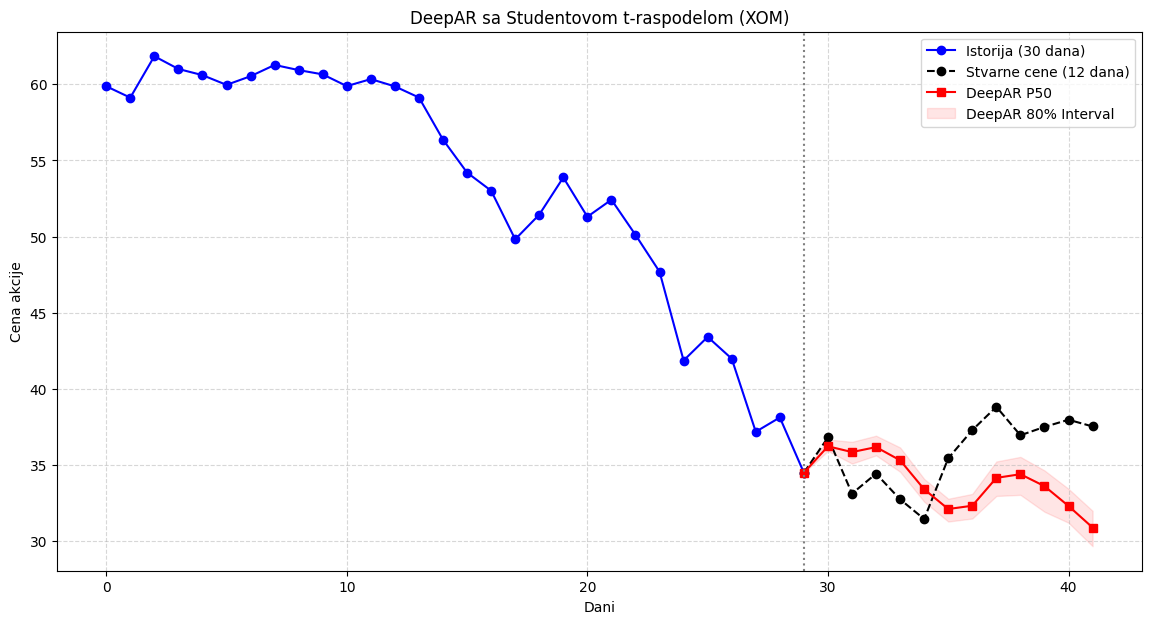

In [ ]:

    target_ticker = df_cutoff.columns[29]
    test_history = df_cutoff[target_ticker].values[-42:-12]
    stvarna_buducnost = df_cutoff[target_ticker].values[-12:]

    predictions = predict(model, df_cutoff, target_ticker, seq_len=seq_len, pred_len=pred_len, num_samples=100)

    p50 = torch.median(predictions, dim=0).values.numpy()
    p10 = torch.quantile(predictions, 0.1, dim=0).numpy()
    p90 = torch.quantile(predictions, 0.9, dim=0).numpy()

    plt.figure(figsize=(14, 7))
    x_istorija = np.arange(seq_len)
    x_predikcija = np.arange(seq_len, seq_len + pred_len)
    x_spojeno = np.concatenate(([x_istorija[-1]], x_predikcija))

    plt.plot(x_istorija, test_history, label="Istorija (30 dana)", color="blue", marker="o")

    y_stvarna = np.concatenate(([test_history[-1]], stvarna_buducnost))
    plt.plot(x_spojeno, y_stvarna, label="Stvarne cene (12 dana)", color="black", linestyle="--", marker="o")

    y_p50 = np.concatenate(([test_history[-1]], p50))
    plt.plot(x_spojeno, y_p50, label="DeepAR P50", color="red", marker="s")

    y_p10 = np.concatenate(([test_history[-1]], p10))
    y_p90 = np.concatenate(([test_history[-1]], p90))
    plt.fill_between(x_spojeno, y_p10, y_p90, color="red", alpha=0.1, label="DeepAR 80% Interval")

    plt.axvline(x=seq_len-1, color="gray", linestyle=":")
    plt.title(f"DeepAR sa Studentovom t-raspodelom ({target_ticker})")
    plt.xlabel("Dani")
    plt.ylabel("Cena akcije")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

In [ ]:
# =========================
# GLOBALNE DEEPAR METRIKE
# =========================

sve_stvarne = []
sve_predikcije = []

for ticker in df_cutoff.columns:

    # stvarne vrednosti u horizontu predikcije
    stvarna = df_cutoff[ticker].values[-pred_len:]

    # shape: (num_samples, pred_len)
    preds = predict(
        model,
        df_cutoff,
        ticker,
        seq_len=seq_len,
        pred_len=pred_len,
        num_samples=100
    )

    sve_stvarne.append(stvarna)
    sve_predikcije.append(preds)

# (num_series, pred_len)
Y_all = np.array(sve_stvarne)

# (num_series, num_samples, pred_len)
P_all = torch.stack(sve_predikcije).cpu().numpy()

# median forecast
p50_all = np.median(P_all, axis=1)

# quantiles
p10_all = np.percentile(P_all, 10, axis=1)
p90_all = np.percentile(P_all, 90, axis=1)

# =========================
# RMSE
# =========================

rmse = np.sqrt(np.mean((Y_all - p50_all) ** 2))

# =========================
# ND (Normalized Deviation)
# =========================

nd = np.sum(np.abs(Y_all - p50_all)) / np.sum(np.abs(Y_all))

# =========================
# Quantile Loss
# =========================

def quantile_loss(y_true, q_pred, rho):
    e = y_true - q_pred
    return np.maximum(rho * e, (rho - 1) * e)

ql_01 = (
    2
    * np.sum(quantile_loss(Y_all, p10_all, 0.1))
    / np.sum(np.abs(Y_all))
)

ql_09 = (
    2
    * np.sum(quantile_loss(Y_all, p90_all, 0.9))
    / np.sum(np.abs(Y_all))
)

print(f"RMSE     = {rmse:.4f}")
print(f"ND       = {nd:.4f}")
print(f"QL(0.1)  = {ql_01:.4f}")
print(f"QL(0.9)  = {ql_09:.4f}")

# =========================
# METRIKE ZA PRVI DAN (t+1)
# =========================

# stvarne vrednosti prvog dana
Y_day1 = Y_all[:, 0]

# uzorci predikcija prvog dana
P_day1 = P_all[:, :, 0]

# median forecast
p50_day1 = np.median(P_day1, axis=1)

# quantiles
p10_day1 = np.percentile(P_day1, 10, axis=1)
p90_day1 = np.percentile(P_day1, 90, axis=1)

# RMSE
rmse_day1 = np.sqrt(np.mean((Y_day1 - p50_day1) ** 2))

# ND
nd_day1 = np.sum(np.abs(Y_day1 - p50_day1)) / np.sum(np.abs(Y_day1))

# Quantile Loss
def quantile_loss(y_true, q_pred, rho):
    e = y_true - q_pred
    return np.maximum(rho * e, (rho - 1) * e)

ql01_day1 = (
    2 * np.sum(quantile_loss(Y_day1, p10_day1, 0.1))
    / np.sum(np.abs(Y_day1))
)

ql09_day1 = (
    2 * np.sum(quantile_loss(Y_day1, p90_day1, 0.9))
    / np.sum(np.abs(Y_day1))
)

print(f"DAY 1 RMSE    = {rmse_day1:.4f}")
print(f"DAY 1 ND      = {nd_day1:.4f}")
print(f"DAY 1 QL(0.1) = {ql01_day1:.4f}")
print(f"DAY 1 QL(0.9) = {ql09_day1:.4f}")

RMSE     = 33.5023
ND       = 0.0726
QL(0.1)  = 0.0462
QL(0.9)  = 0.0420
DAY 1 RMSE    = 23.1140
DAY 1 ND      = 0.0553
DAY 1 QL(0.1) = 0.0217
DAY 1 QL(0.9) = 0.0588
